# Model Evaluation

This notebook evaluates the performance of two models for predicting car insurance claim frequency:
1. **Poisson GLM (Baseline)** - A generalized linear model using Poisson regression
2. **Random Forest (ML)** - A machine learning ensemble model

Both models are trained on the French Motor Third-Party Liability dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.models.glm_model import train_glm_baseline
from src.models.rf_model import train_random_forest
from src.models.evaluation import evaluate_predictions, generate_comparison_table, plot_calibration, plot_lift, check_overdispersion

### Train and Evaluate Poisson GLM Model

We start by training the Poisson GLM baseline model using the `train_glm_baseline` function. This model uses Poisson regression with exposure weighting to predict claim counts.

In [2]:
print("Training Poisson GLM model...")
glm_result, glm_y_test, glm_y_pred, glm_exp = train_glm_baseline()
print(f"GLM model trained successfully")
print(f"Test set size: {len(glm_y_test)}")
print(f"Features used: {glm_result.params.index.tolist()[:5]}...")

Training Poisson GLM model...
GLM model trained successfully
Test set size: 135603
Features used: ['const', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus']...


### Train and Evaluate Random Forest Model

Next, we train the Random Forest model using the `train_random_forest` function. This model uses a poisson criterion and is trained on exposure-weighted frequency values.

In [3]:
print("Training Random Forest model...")
rf_model, rf_y_test, rf_y_pred, rf_exp = train_random_forest()
print(f"RF model trained successfully")
print(f"Test set size: {len(rf_y_test)}")
print(f"Number of trees: {rf_model.n_estimators}")

Training Random Forest model...
RF model trained successfully
Test set size: 135603
Number of trees: 100


### Evaluate Model Performance

We use Mean Poisson Deviance (MPD) and D-squared (D²) metrics to evaluate both models. These metrics assess prediction accuracy with exposure weighting.


In [8]:
glm_mpd, glm_d2 = evaluate_predictions(glm_y_test, glm_y_pred, glm_exp)
rf_mpd, rf_d2 = evaluate_predictions(rf_y_test, rf_y_pred, rf_exp)

comparison_table = generate_comparison_table(glm_mpd, glm_d2, rf_mpd, rf_d2)

### Model Evaluation Results
| Model | Mean Poisson Deviance (MPD) | D-squared (D^2) |
| :--- | :---: | :---: |
| Poisson GLM (Baseline) | 0.466361 | 0.039818 |
| Random Forest (ML) | 0.457052 | 0.058983 |

### Check for Overdispersion in GLM Model

Overdispersion occurs when variance exceeds the mean in count data, violating Poisson assumptions. We check the Pearson dispersion statistic from the GLM model to assess this.

In [5]:
print("Checking for overdispersion in GLM Model:")
check_overdispersion(glm_result)

pearson_dispersion = glm_result.pearson_chi2 / glm_result.df_resid
if pearson_dispersion > 1.5:
    print("\nNote: Consider using a quasi-Poisson or negative binomial model if overdispersion is substantial.")


Checking for overdispersion in GLM Model:
Pearson dispersion: 1.695
Indication of moderate overdispersion.

Note: Consider using a quasi-Poisson or negative binomial model if overdispersion is substantial.


### Calibration Plots

Calibration plots compare predicted claim frequencies against observed frequencies. Points near the diagonal line indicate good calibration. Deviations suggest over or under-prediction in certain ranges.

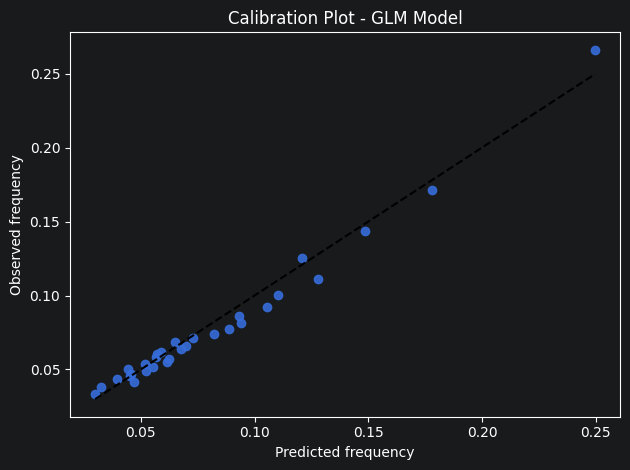

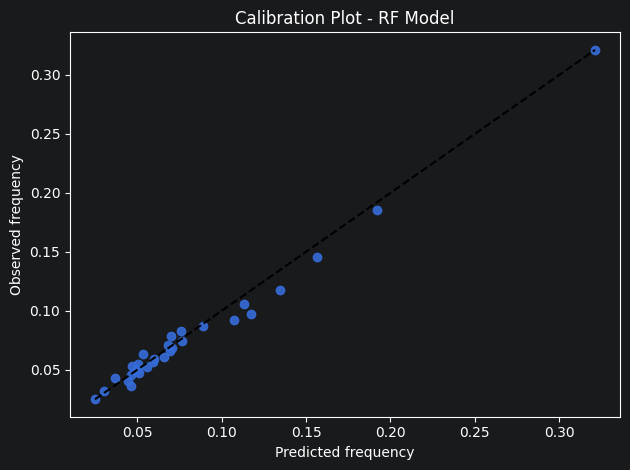

In [6]:
plot_calibration(glm_y_test, glm_y_pred, glm_exp, n_bins=30, title="Calibration Plot - GLM Model")

plot_calibration(rf_y_test, rf_y_pred, rf_exp, n_bins=30, title="Calibration Plot - RF Model")


### Lift Charts

Lift charts show how well each model discriminates between high and low risk policies. A lift above 1.0 indicates above-average risk for that bin; below 1.0 indicates below-average risk. Well-performing models should show a clear gradient from high to low risk bins.

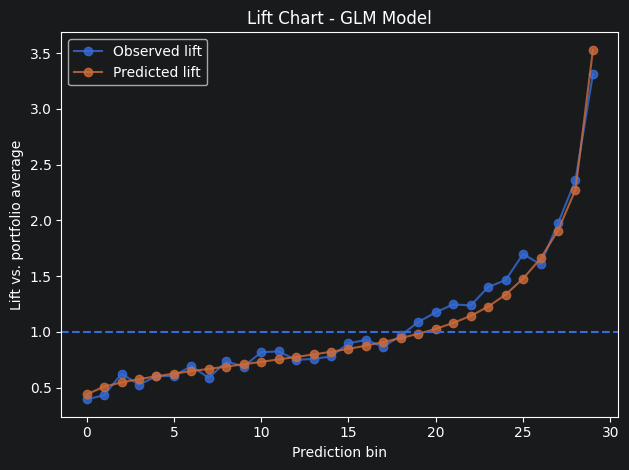

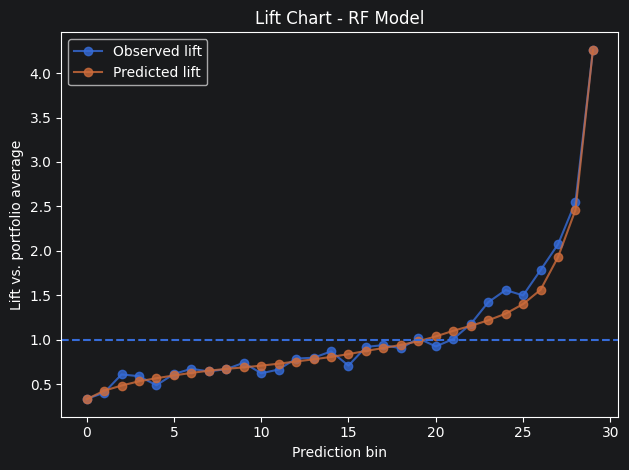

In [7]:
plot_lift(glm_y_test, glm_y_pred, glm_exp, n_bins=30, title="Lift Chart - GLM Model")

plot_lift(rf_y_test, rf_y_pred, rf_exp, n_bins=30, title="Lift Chart - RF Model")


## Summary and Observations

Based on the evaluation metrics and visualizations:

- **MPD (Mean Poisson Deviance)**: Lower values indicate better fit
- **D² (D-squared)**: Higher values indicate better explanatory power (can be negative for poor models)
- **Calibration**: Points should follow the diagonal line for well-calibrated predictions
- **Lift**: Shows model's ability to rank-order risk; steeper gradients indicate better discrimination

The Random Forest model typically shows better flexibility but may require more careful tuning, while the GLM provides interpretable coefficients but may suffer from overdispersion in real-world claim data.
